In [1]:
import awkward as ak

In [18]:
zh_path = "/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260206/zh_train.parquet"
zz_path = "/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260206/zz_train.parquet"
qq_path = "/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260206/qq_test.parquet"
# z_path = "/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260206/z_test.parquet"

zz_data = ak.from_parquet(zz_path)
zh_data = ak.from_parquet(zh_path)
qq_data = ak.from_parquet(qq_path)
# z_data = ak.from_parquet(z_path)


# As Z data is not jet merged:
from ntupelizer.aleph.tools.io import load_all_data
z_data = load_all_data("/local/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/p8_ee_Z_qq_ecm91/")


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:37<00:00,  1.34it/s]


Input data loaded


In [4]:
from ntupelizer.tools.general import reinitialize_p4

In [19]:
zz_jet_pt = reinitialize_p4(zz_data.reco_jet_p4s).pt
zh_jet_pt = reinitialize_p4(zh_data.reco_jet_p4s).pt
qq_jet_pt = reinitialize_p4(qq_data.reco_jet_p4s).pt
z_jet_pt = reinitialize_p4(z_data.reco_jet_p4s).pt

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

plt.style.use(hep.style.CMS)


def plot_distributions_with_ratio(
    data1, data2, data3, data4,
    labels=("ZZ", "ZH", "Z", "qq"),
    colors=("blue", "red", "green", "black"),
    xlabel="Variable",
    ylabel="Events",
    xscale="log",
    n_bins=50,
    hist_range=None,
):
    fig, (ax_main, ax_ratio) = plt.subplots(
        2, 1, gridspec_kw={"height_ratios": [3, 1]}, sharex=True, figsize=(10, 8)
    )
    fig.subplots_adjust(hspace=0.05)

    if hist_range is None:
        all_data = np.concatenate([data1, data2, data3, data4])
        positive = all_data[all_data > 0]
        hist_range = (np.min(positive), np.max(positive))

    if xscale == "log":
        bins = np.logspace(np.log10(hist_range[0]), np.log10(hist_range[1]), n_bins + 1)
    else:
        bins = np.linspace(hist_range[0], hist_range[1], n_bins + 1)

    h1, _ = np.histogram(data1, bins=bins, density=True)
    h2, _ = np.histogram(data2, bins=bins, density=True)
    h3, _ = np.histogram(data3, bins=bins, density=True)
    h4, _ = np.histogram(data4, bins=bins, density=True)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])

    hep.histplot([h1, h2, h3, h4], bins=bins, label=labels, color=colors, ax=ax_main)
    ax_main.set_ylabel(ylabel)
    ax_main.set_yscale('log')
    ax_main.set_xscale(xscale)
    ax_main.legend(frameon=True, edgecolor="black", fancybox=False)

    # Ratio plots: dataset/dataset4
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio1 = np.where(h4 > 0, h1 / h4, np.nan)
        ratio2 = np.where(h4 > 0, h2 / h4, np.nan)
        ratio3 = np.where(h4 > 0, h3 / h4, np.nan)

    ax_ratio.errorbar(bin_centers, ratio1, fmt="o", color=colors[0], label=f"{labels[0]} / {labels[3]}", markersize=4)
    ax_ratio.errorbar(bin_centers, ratio2, fmt="s", color=colors[1], label=f"{labels[1]} / {labels[3]}", markersize=4)
    ax_ratio.errorbar(bin_centers, ratio3, fmt="^", color=colors[2], label=f"{labels[2]} / {labels[3]}", markersize=4)
    ax_ratio.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax_ratio.set_ylabel("Ratio")
    ax_ratio.set_xlabel(xlabel)
    ax_ratio.set_xscale(xscale)
    ax_ratio.set_yscale('log')
    ax_ratio.legend(fontsize=12, frameon=True, edgecolor="black", fancybox=False, loc='upper right')

    return fig, (ax_main, ax_ratio)

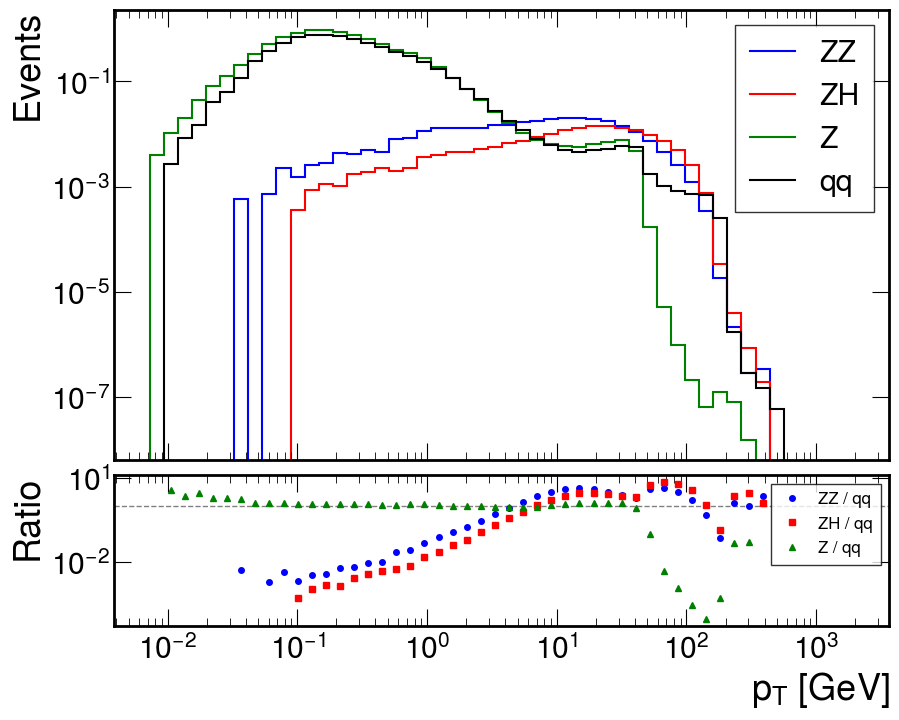

In [57]:
fig, axes = plot_distributions_with_ratio(
    zz_jet_pt, zh_jet_pt, z_jet_pt, qq_jet_pt,
    labels=("ZZ", "ZH", "Z", "qq"),
    xlabel=r"$p_T$ [GeV]",
)
fig.savefig("/home/laurits/tmp/pt_distribution.pdf", format="pdf")

In [48]:
zz_jet_count = ak.num(zz_data.reco_cand_charge)
zh_jet_count = ak.num(zh_data.reco_cand_charge)
qq_jet_count = ak.num(qq_data.reco_cand_charge)
z_jet_count = ak.num(z_data.reco_cand_charge)

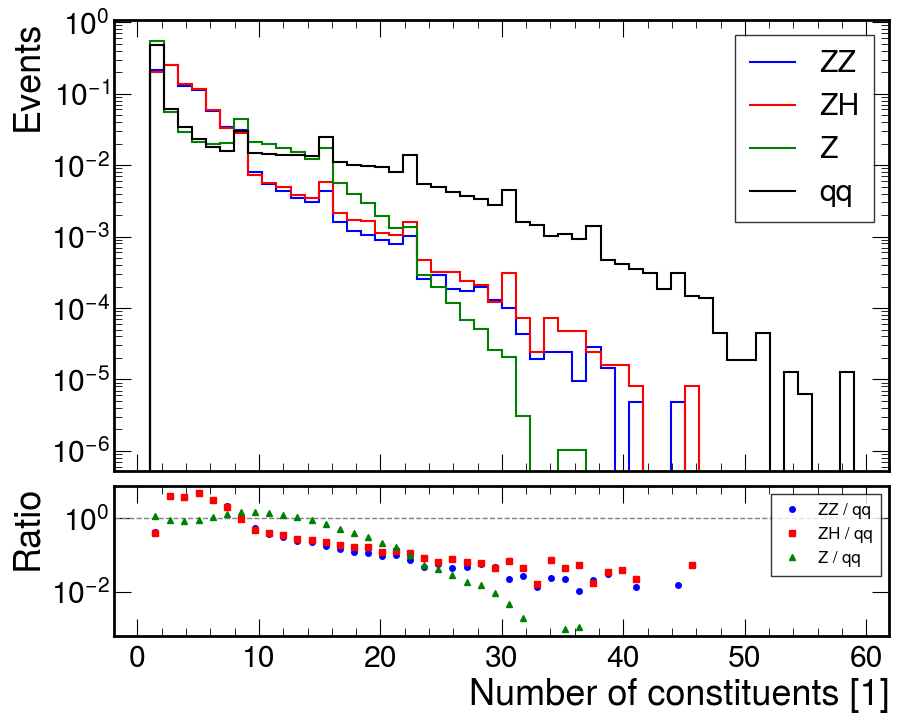

In [58]:
fig, axes = plot_distributions_with_ratio(
    zz_jet_count, zh_jet_count, z_jet_count, qq_jet_count,
    labels=("ZZ", "ZH", "Z", "qq"),
    xlabel=r"Number of constituents [1]",
    xscale="linear"
)
fig.savefig("/home/laurits/tmp/constCount_distribution.pdf", format="pdf")


In [64]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplhep as hep

plt.style.use(hep.style.CMS)


def plot_2d_heatmap(
    x_data, y_data,
    xlabel="Number of jet constituents",
    ylabel=r"Candidate $p_T$ [GeV]",
    title="",
    x_bins=None,
    y_bins=50,
    y_log=True,
    log_colorbar=True,
    fig=None, ax=None,
    norm=None,
):
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Integer bins for jet constituents
    if x_bins is None:
        x_bins = np.arange(int(np.min(x_data)) - 0.5, int(np.max(x_data)) + 1.5, 1)

    # Log-spaced bins for pT
    if y_log:
        positive_y = y_data[y_data > 0]
        y_bins = np.logspace(np.log10(np.min(positive_y)), np.log10(np.max(positive_y)), y_bins + 1)

    if norm is None and log_colorbar:
        norm = mcolors.LogNorm()

    h, xedges, yedges, im = ax.hist2d(
        x_data, y_data, bins=[x_bins, y_bins], norm=norm, cmap="viridis", cmin=1,
    )

    if y_log:
        ax.set_yscale("log")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    return fig, ax, im

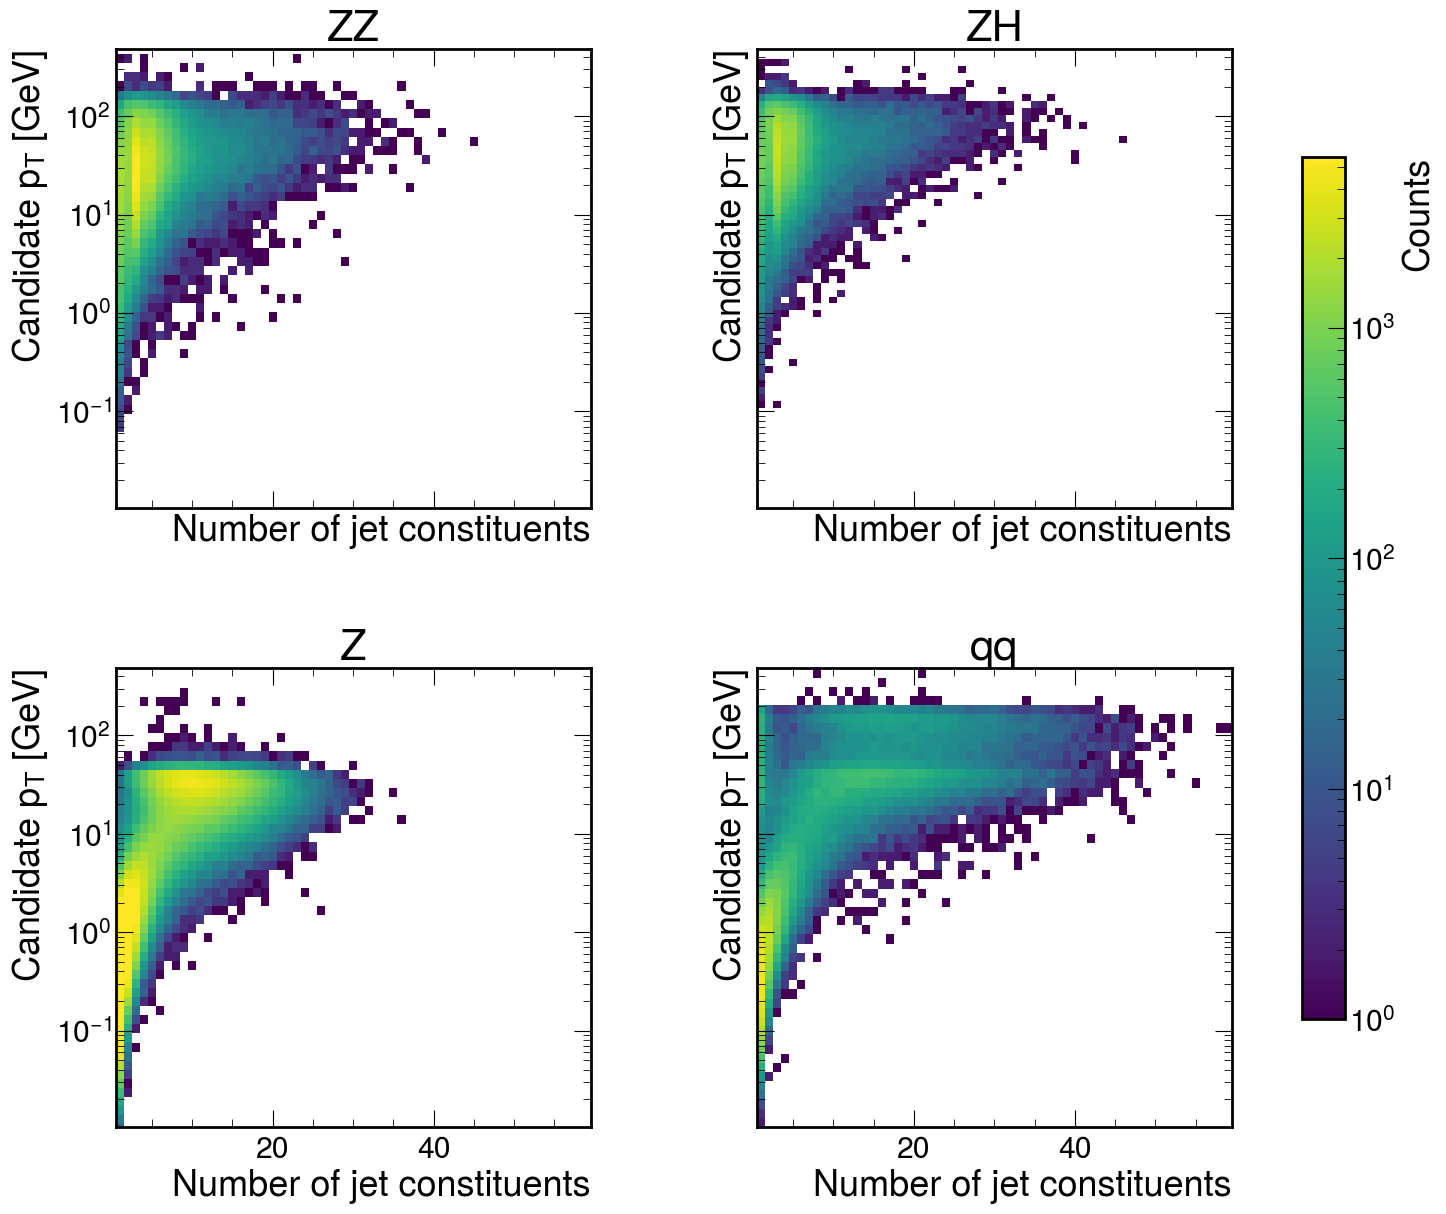

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.35, wspace=0.35)

datasets = [
    (zz_jet_count, zz_jet_pt, "ZZ"),
    (zh_jet_count, zh_jet_pt, "ZH"),
    (z_jet_count, z_jet_pt, "Z"),
    (qq_jet_count, qq_jet_pt, "qq"),
]

norm = mcolors.LogNorm()

for ax, (x, y, label) in zip(axes.flat, datasets):
    _, _, im = plot_2d_heatmap(x, y, title=label, fig=fig, ax=ax, norm=norm)

fig.colorbar(im, ax=axes.ravel().tolist(), label="Counts", shrink=0.8)
plt.savefig("/home/laurits/tmp/2d_pt_v_constituentCount.pdf", format="pdf")